# Controlled Gates

In this tutorial, we will discuss controlled gates and using them in Workbench code.

In Workbench, gates are represented as the methods of the `Qubits` class. The same method can be used to invoke several related gates, depending on the arguments passed to it. For example, the `x()` method can be used to apply a single $X$ gate to one qubit, several $X$ gates to different qubits, a controlled-$X$ gate, or a sequence of controlled-$X$ gates. 
In the [previous tutorial](./Basic-Gates.ipynb), we introduced the "basic" gates - gates that are not represented as controlled variants of other gates. 
In this tutorial, we will discuss generating controlled gates from these basic gates.


## Applying regular controlled gates

Let's say you need to apply a controlled variant of a gate $U$, and you know that the method `u()` applies the uncontrolled variant of this gate. (This method might take extra arguments, such as rotation angles or a bit mask which specifies the target subset of qubits.) To do this, you can modify the method call to include an extra argument `cond` - the `Qubits` object which specifies the control register of the gate. As usual, you can use either entire `Qubits` object or a slice of an object as this argument.

The following example shows how to apply several variants of an $X$ gate: an uncontrolled $X$ gate, a $CX$ gate (an $X$ gate with one control qubit), and a $CCX$ gate (an $X$ gate with two control qubits). Each variant is included twice: first as a single-target instruction (an instruction that generates a single gate) and then as a multi-target instruction (an instruction that generates several gates with the same control register but different targets).

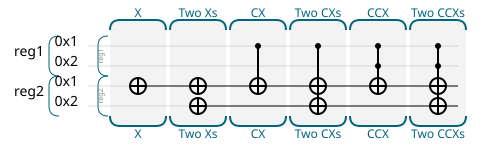

In [1]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=4)
reg1, reg2 = Qubits(2, "reg1", qpu), Qubits(2, "reg2", qpu)

qpu.label("X")
qpu.nop()
reg2[0].x()
qpu.nop()

qpu.label("Two Xs")
reg2.x()

qpu.label("CX")
qpu.nop()
reg2[0].x(cond=reg1[0])
qpu.nop()

qpu.label("Two CXs")
reg2.x(cond=reg1[0])

qpu.label("CCX")
reg2[0].x(cond=reg1)

qpu.label("Two CCXs")
reg2.x(cond=reg1)

qpu.draw()

The only limitation on the qubit registers which act as the targets and the conditions is that they cannot share any qubits. Other than that, you can use any `Qubits` objects as targets and conditions, including objects obtained by slicing and concatenation of different registers. The following example illustrates this.

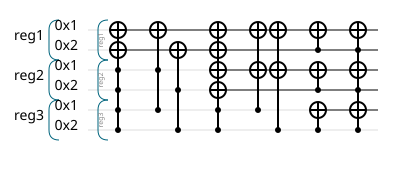

In [2]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=6)
reg1, reg2, reg3 = Qubits(2, "reg1", qpu), Qubits(2, "reg2", qpu), Qubits(2, "reg3", qpu)

# Control is concatenation of two registers
reg1.x(cond=reg2 | reg3)
qpu.nop()

# Control is concatenation of two register slices
for ind in range(2):
    reg1[ind].x(cond=reg2[ind] | reg3[ind])
qpu.nop()

# Target is concatenation of two registers
(reg1 | reg2).x(cond=reg3)
qpu.nop()

# Target is concatenation of two register slices
for ind in range(2):
    (reg1[0] | reg2[0]).x(cond=reg3[ind])
qpu.nop()

# Control and target are slices of the same register
for reg in [reg1, reg2, reg3]:
    reg[0].x(cond=reg[1])
qpu.nop()

# Control and target are concatenations of slices of the same registers
(reg1[0] | reg2[0] | reg3[0]).x(cond=reg1[1] | reg2[1] | reg3[1])
qpu.nop()

qpu.draw()

## Modifying cond_xor masks

When we introduced the `Qubits` data type, we mentioned that one of its data fields is the bit mask `cond_xor` that specifies the behavior of this object when it is used as a control register for a quantum gate. 

When a `Qubits` object is allocated, its mask is `0`, indicating that all qubits should be used as they are, without inverting any of them. Using this object as a control leads to a regular controlled gate, that is, a gate that is applied to the target qubit(s) if all control qubits are in the $|1\rangle$ state.

Later in your code, you can modify the mask of a `Qubits` object to specify that some qubits should be inverted when this object is used as a control register. This allows to express other types of controlled gates concisely.

For example,

* `~reg` is a negation of register `reg`: it consists of the same qubits as `reg` but has its bit mask inverted. 
* `reg ^ 1` is the register `reg` with just its least significant qubit inverted. 
* `reg[:-1] | ~reg[-1]` is the register `reg` with its most significant qubit inverted (obtained by concatenating all qubits except the last one with the negation of the last qubit).

The following code snippet allocates two `Qubits` registers and shows the masks that describe their structure, followed by examples of objects created by inverting the whole register or only its least/most significant qubit.

In [3]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=4)
reg1, reg2 = Qubits(2, "reg1", qpu), Qubits(2, "reg2", qpu)

print(f"reg1: qubits {reg1.qubit_indices()}")
print(f"Qubits mask   {reg1.mask()} = {bin(reg1.mask())}")
print(f"cond_xor mask {reg1.cond_xor} = {bin(reg1.cond_xor)}\n")

not_reg1 = ~reg1

print(f"~reg1: qubits {not_reg1.qubit_indices()}")
print(f"Qubits mask   {reg1.mask()} = {bin(reg1.mask())}")
print(f"cond_xor mask {not_reg1.cond_xor} = {bin(not_reg1.cond_xor)}\n")

lsb_reg1 = reg1 ^ 1

print(f"reg1 ^ 1: qubits {lsb_reg1.qubit_indices()}")
print(f"Qubits mask   {lsb_reg1.mask()} = {bin(lsb_reg1.mask())}")
print(f"cond_xor mask {lsb_reg1.cond_xor} = {bin(lsb_reg1.cond_xor)}\n")

print(f"reg2: qubits {reg2.qubit_indices()}")
print(f"Qubits mask   {reg2.mask()} = {bin(reg2.mask())}")
print(f"cond_xor mask {reg2.cond_xor} = {bin(reg2.cond_xor)}\n")

not_reg2 = ~reg2

print(f"~reg2: qubits {not_reg2.qubit_indices()}")
print(f"Qubits mask   {reg2.mask()} = {bin(reg2.mask())}")
print(f"cond_xor mask {not_reg2.cond_xor} = {bin(not_reg2.cond_xor)}\n")

msb_reg2 = reg2[:-1] | ~reg2[-1]

print(f"reg2[:-1] | ~reg2[-1]: qubits {msb_reg2.qubit_indices()}")
print(f"Qubits mask   {msb_reg2.mask()} = {bin(msb_reg2.mask())}")
print(f"cond_xor mask {msb_reg2.cond_xor} = {bin(msb_reg2.cond_xor)}")

reg1: qubits (0, 1)
Qubits mask   3 = 0b11
cond_xor mask 0 = 0b0

~reg1: qubits (0, 1)
Qubits mask   3 = 0b11
cond_xor mask 3 = 0b11

reg1 ^ 1: qubits (0, 1)
Qubits mask   3 = 0b11
cond_xor mask 1 = 0b1

reg2: qubits (2, 3)
Qubits mask   12 = 0b1100
cond_xor mask 0 = 0b0

~reg2: qubits (2, 3)
Qubits mask   12 = 0b1100
cond_xor mask 12 = 0b1100

reg2[:-1] | ~reg2[-1]: qubits (2, 3)
Qubits mask   12 = 0b1100
cond_xor mask 8 = 0b1000


> You can also modify the `cond_xor` mask directly. However, you can see that the value of the `cond_xor` mask depends not only on the relative indices of inverted qubits within the `Qubits` object, but also on the absolute indices of the qubits within that object in the QPU. 
(Indeed, `~reg1` and `~reg2` each represent a two-qubit register with both qubits inverted, but their `cond_xor` masks are different.)
We strongly recommend modifying the conditions on qubit registers be manipulating `Qubits` objects themselves rather than their fields.

## Applying controlled gates with different control patterns

Workbench offers two main ways to apply a controlled gate with a control pattern other than the all-$|1\rangle$ state:

* Use a `Qubits` register as the `cond` argument. The `cond_xor` mask of the control register specifies the control pattern.
* Use the result of comparison of a `Qubits` register with a constant as the `cond` argument. The constant used in the comparison specifies the control pattern. As usual, the integer constant is converted to a bit string using little-endian encoding, the least significant bit corresponding to the first qubit (the top wire).

> Workbench offers a variety of other, more sophisticated ways to apply a quantum gate conditioned on an outcome of a computation.
However, these conditionals are represented using sequences of gates rather than a single controlled gates and rely on Workbench tools such as [uncomputation](./Qubricks-Uncomputation.ipynb) and [arithmetic](./Quantum-Arithmetic.ipynb) which we haven't discussed yet. We will return to the discussion of conditional computations in a [later tutorial](./Qubricks-Computed-Context-Manager.ipynb).

The following example shows several sets of equivalent controlled gates applied using different expressions as control conditions.

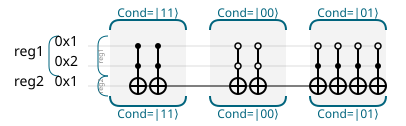

In [4]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=3)
reg1, reg2 = Qubits(2, "reg1", qpu), Qubits(1, "reg2", qpu)

qpu.label("Cond=|11⟩")
# Regular controlled gate
reg2.x(cond=reg1)

# Regular controlled gate as controlled-on-integer
reg2.x(cond=reg1 == 3)
qpu.label()
qpu.nop()

qpu.label("Cond=|00⟩")
# Controlled-on-zero gate applied by controlling on inverted register
reg2.x(cond=~reg1)

# Controlled-on-zero gate applied as controlled-on-integer
reg2.x(cond=reg1 == 0)
qpu.label()
qpu.nop()

qpu.label("Cond=|01⟩")
# Controlled-on-integer gate
reg2.x(cond=reg1 == 2)

# Same gate applied as controlled-on-bitmask
reg2.x(cond=reg1 == 0b10)

# Same gate applied as controlled on a register with its least significant bit inverted
reg2.x(cond=reg1 ^ 1)

# Same gate applied as controlled on a register composed of slices, some of them inverted
reg2.x(cond=~reg1[0] | reg1[1])

qpu.draw()

## Applying controlled gates to a subset of qubits using bit masks

Same as for the basic gates, you can specify the targets of a controlled gate using a bit mask to address specific qubits within the target register. 
In this case, the first argument of the gate method is the target bit mask, and the second argument the condition. 

> We recommend you to use the keyword `cond` to pass the control condition to the gate. This improves code readability and makes it easier to maintain.

The following example shows how to implement a simple data lookup circuit which loads classical data from a list into two qubit registers, index and data. The circuit performs the following transformation: given an index register in the basis state $k$ and a data register in the $|0\rangle$ state, it loads the list element with index $k$ into the data register:

$$|k\rangle_{index} |0\rangle_{data} \rightarrow |k\rangle_{index} |a_{k}\rangle_{data}$$

The code iterates over the indices of the input data and applies a controlled gate for each index $k$. This gate uses the list element with index $k$ as the target bit mask (to specify the data which is loaded into the target register) and the index $k$ itself as the control pattern (to specify the condition of loading this data element).

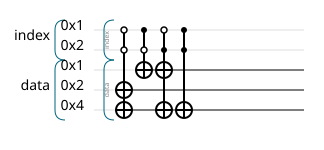

In [5]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=5)
index, data = Qubits(2, "index", qpu), Qubits(3, "data", qpu)

data_int = [6, 1, 5, 4]
for k in range(len(data_int)):
    data.x(data_int[k], cond=index == k)

qpu.draw()

## Applying multiple controlled gates with one instruction

By default, one Workbench instruction creates either one controlled gate or a multi-target controlled gate (a series of gates with the same control register and different targets). However, sometimes it is convenient to create a ladder of controlled gates between matching qubits of two registers. A typical example of such scenario is computing XOR of two qubit registers which requires a ladder of controlled-$X$ gates.

To do this, you can use any Workbench gate with the `cond_zip` argument which specifies the register of control qubits to pair with the target qubits. Each of the gates applied by this instruction will connect the matching qubits of the registers with a single-controlled gate. (If the registers are of different lengths, the number of gates applied will equal the length of the shorter register.)

The following example illustrates the use of `cond_zip` argument. You can see that by changing the argument you can modify the order in which the qubits of two registers are mapped to each other and the control patterns of the gates. You can also combine the arguments `cond` and `cond_zip` to keep some of the control qubits fixed while varying the others.

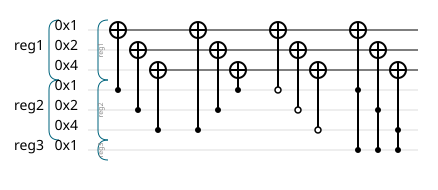

In [6]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=7)
reg1, reg2, reg3 = Qubits(3, "reg1", qpu), Qubits(3, "reg2", qpu), Qubits(1, "reg3", qpu)

# Controlled gates between matching qubits of two registers
reg1.x(cond_zip=reg2)
qpu.nop()

# Controlled gates between matching qubits of two registers, one of them in reverse order
reg1.x(cond_zip=reg2[::-1])
qpu.nop()

# Controlled-on-zero gates between matching qubits of two registers
reg1.x(cond_zip=~reg2)
qpu.nop()

# Controlled gates between matching qubits of two registers with an extra fixed control qubit
reg1.x(cond=reg3, cond_zip=reg2)
qpu.nop()
qpu.draw()

## Next steps

You have learned about applying controlled gates in your Workbench programs. In the next tutorial, you will learn how to use [measurements](./Measurements.ipynb) for information readout.